# Instrumental variables

Code adapted by this website: https://matheusfacure.github.io/python-causality-handbook/08-Instrumental-Variables.html#the-1st-stage

In [1]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels.iv import IV2SLS

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

Goal is to estimate the impact of years of schooling on log wages. 
\begin{equation*}
\log (\text{wage}) = \alpha + \beta \text{education} + \gamma \text{ability} + \epsilon
\end{equation*}
Here, ability is an unobserved confounder.
If you regress wages on years of education, you will get biased results.

To find the effect of interest, $\beta$, we can use an instrumental variable $z$, that is uncorrelated with ability, but correlated with years of education.
Quarter of birth may be that instrument.
While it varies by state, children born at the end of the year start school younger. 
Compulsory education ends when a child turns 16, so those who began school younger were more likely to have more schooling.
* Quarter of birth is independent of a person's ability
* People born in the fourth quarter of the year have, on average, more years of education than those born earlier in the year.

$\implies$ quarter of birth is a valid and relevant instrument

In [2]:
# data from the companion site
url = "https://raw.githubusercontent.com/matheusfacure/python-causality-handbook/refs/heads/master/causal-inference-for-the-brave-and-true/data/ak91.csv"

df = pd.read_csv(url)
df.head()

,log_wage,years_of_schooling,year_of_birth,quarter_of_birth,state_of_birth
0,5.790019,12.0,30.0,1.0,45.0
1,5.952494,11.0,30.0,1.0,45.0
2,5.315949,12.0,30.0,1.0,45.0
3,5.595926,12.0,30.0,1.0,45.0
4,6.068915,12.0,30.0,1.0,37.0


## Assumptions

### Relevance

Consider whether the instrument is:

1. Relevant: $\text{Cov} (z, p) = 0$
    * Quarter of birth ($z$) is correlated with confounded treatment variable (years of education, $p$)
2. Valid [Exclusion restriction]: $y \perp z \vert p$
    * Quarter of birth ($z$) is independent of wages ($y$), conditional on years of education ($p$)
    * Instrument only impacts outcome variable through treatment, $p$

For relevance, we expect there to be a relationship between quarter of birth and years of education. 

<Axes: xlabel='Year of Birth', ylabel='years_of_schooling'>

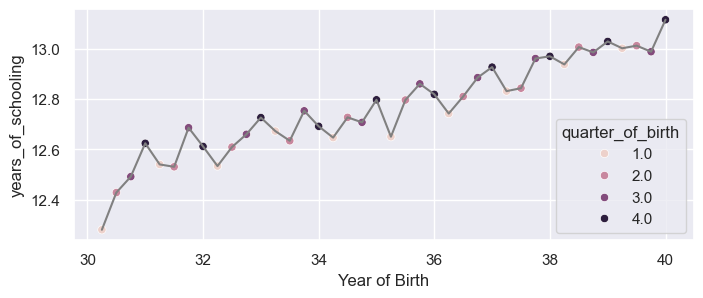

In [3]:
plot_df = df.groupby(['year_of_birth', 'quarter_of_birth'])['years_of_schooling'].mean().reset_index()

plot_df['Year of Birth'] = plot_df['year_of_birth'] + (plot_df['quarter_of_birth'] / 4)

fig, ax = plt.subplots(figsize=(8, 3))

sns.lineplot(x=plot_df['Year of Birth'], y=plot_df['years_of_schooling'], color='gray')
sns.scatterplot(x=plot_df['Year of Birth'], y=plot_df['years_of_schooling'], hue=plot_df['quarter_of_birth'])

Those born in the fourth quarter tend to have more education. Can also verify this with linear regression

In [4]:
# add dummies for quarter of birth
q_var = pd.get_dummies(df['quarter_of_birth'])
col_var = 'q' + q_var.columns.astype(int).astype(str)
df[col_var] = q_var

df.head()

,log_wage,years_of_schooling,year_of_birth,quarter_of_birth,state_of_birth,q1,q2,q3,q4
0,5.790019,12.0,30.0,1.0,45.0,True,False,False,False
1,5.952494,11.0,30.0,1.0,45.0,True,False,False,False
2,5.315949,12.0,30.0,1.0,45.0,True,False,False,False
3,5.595926,12.0,30.0,1.0,45.0,True,False,False,False
4,6.068915,12.0,30.0,1.0,37.0,True,False,False,False


In [5]:
first_stage = smf.ols("years_of_schooling ~ C(year_of_birth) + C(state_of_birth) + q4", data=df).fit()

print("q4 parameter estimate:, ", first_stage.params["q4[T.True]"])
print("q4 p-value:, ", first_stage.pvalues["q4[T.True]"])

q4 parameter estimate:,  0.10085809272829056
q4 p-value:,  5.464829415104939e-15


Those born in Q4 on average have .1 more years of education than those born in other quarters.

### Validity

The validity assumption cannot be verified.
<!-- You have to be ab÷le to argue that quarter of birth doesn't have an impact on ability, except through years of schooling. -->

<Axes: xlabel='Year of Birth', ylabel='log_wage'>

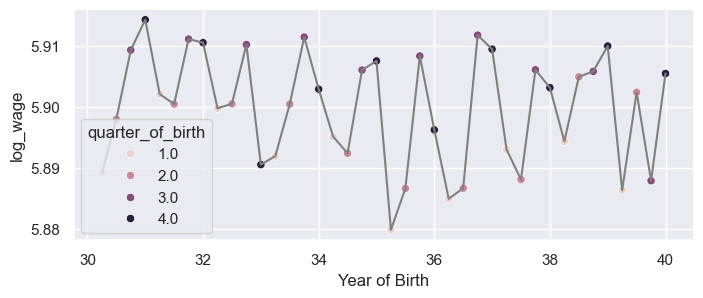

In [6]:
plot_df = df.groupby(['year_of_birth', 'quarter_of_birth'])['log_wage'].mean().reset_index()

plot_df['Year of Birth'] = plot_df['year_of_birth'] + (plot_df['quarter_of_birth'] / 4)

fig, ax = plt.subplots(figsize=(8, 3))

sns.lineplot(x=plot_df['Year of Birth'], y=plot_df['log_wage'], color='gray')
sns.scatterplot(x=plot_df['Year of Birth'], y=plot_df['log_wage'], hue=plot_df['quarter_of_birth'])

## Equivalency of estimation types

First, to show equivalency of estimation types, let's consider the specification that controls for being born in Q4, with no other covariates

### Calculate reduced form and first stage, and calculate the ratio

In [7]:
result_types = {}

In [8]:
df.groupby('state_of_birth')['log_wage'].agg(['mean', 'count']).sort_values(by='count', ascending=False)

df_42 = df.loc[df['state_of_birth'] == 42]

In [9]:
reg_str = (
    'years_of_schooling ~ q4'
)
ols_mod = smf.ols(formula=reg_str, data=df_42)
first_stage = ols_mod.fit()

print(f"q4 parameter estimate: {first_stage.params['q4[T.True]']:.4f}")
print(f"q4 p-value: {first_stage.pvalues['q4[T.True]']:.4f}")

q4 parameter estimate: 0.0419
q4 p-value: 0.3260


In [10]:
reg_str = (
    'log_wage ~ q4'
)
ols_mod = smf.ols(formula=reg_str, data=df_42)
reduced_form = ols_mod.fit()

print(f"q4 parameter estimate: {reduced_form.params['q4[T.True]']:.4f}")
print(f"q4 p-value: {reduced_form.pvalues['q4[T.True]']:.4f}")

q4 parameter estimate: 0.0069
q4 p-value: 0.4372


In [11]:
result_types['iv_by_hand'] = reduced_form.params['q4[T.True]'] / first_stage.params['q4[T.True]']
result_types['iv_by_hand'] 

np.float64(0.16432381915738878)

### Calculate Wald estimate

In [12]:
mean_T_given_Z = df_42.groupby('q4')['years_of_schooling'].mean()

mean_Y_given_Z = df_42.groupby('q4')['log_wage'].mean()

result_types['wald'] = (mean_Y_given_Z[True] - mean_Y_given_Z[False]) / (mean_T_given_Z[True] - mean_T_given_Z[False])
result_types['wald']

np.float64(0.16432381916100555)

### 2SLS

In [13]:
df_42.head()

,log_wage,years_of_schooling,year_of_birth,quarter_of_birth,state_of_birth,q1,q2,q3,q4
163,5.847161,12.0,30.0,1.0,42.0,True,False,False,False
184,5.745004,11.0,30.0,1.0,42.0,True,False,False,False
193,6.193767,14.0,30.0,1.0,42.0,True,False,False,False
220,-0.732368,8.0,30.0,1.0,42.0,True,False,False,False
223,5.635819,12.0,30.0,1.0,42.0,True,False,False,False


In [14]:
def parse(mod_result, exog="years_of_schooling"):
    param = mod_result.params[exog]
    se = mod_result.std_errors[exog]
    p_val = mod_result.pvalues[exog]
    print(f"Parameter: {param:.3f}")
    print(f"SE: {se:.3f}")
    print(f"P-value: {p_val:.3f}")

In [15]:
reg_str = (
    'log_wage ~ 1 + [years_of_schooling ~ q4]'
)
iv_mod = IV2SLS.from_formula(data=df_42, formula=reg_str)
iv_res = iv_mod.fit(cov_type='unadjusted')

result_types['2sls_from_formula'] = iv_res.params['years_of_schooling']

parse(iv_res)

Parameter: 0.164
SE: 0.222
P-value: 0.460


In [16]:
exog = sm.add_constant(df_42['q4']).drop(columns='q4')

# endogenous variable: treatment t
endog = df_42['years_of_schooling']
# dependent: outcome variable y
dependent = df_42['log_wage']
instrument = df_42['q4']

iv_mod = IV2SLS(dependent, exog, endog, instrument)
iv_res = iv_mod.fit(cov_type='unadjusted')

result_types['2sls'] = iv_res.params['years_of_schooling']

parse(iv_res)


Parameter: 0.164
SE: 0.222
P-value: 0.460


In [17]:
pd.Series(result_types)

iv_by_hand           0.164324
wald                 0.164324
2sls_from_formula    0.164324
2sls                 0.164324
dtype: float64

## Adding controls

### By hand

In [18]:
reg_str = (
    'years_of_schooling ~ C(year_of_birth) + C(state_of_birth) + q4'
)
ols_mod = smf.ols(formula=reg_str, data=df)
first_stage = ols_mod.fit()

print(f"q4 parameter estimate: {first_stage.params['q4[T.True]']:.4f}")
print(f"q4 p-value: {first_stage.pvalues['q4[T.True]']:.4f}")

q4 parameter estimate: 0.1009
q4 p-value: 0.0000


In [19]:
reg_str = (
    'log_wage ~ C(year_of_birth) + C(state_of_birth) + q4'
)
ols_mod = smf.ols(formula=reg_str, data=df)
reduced_form = ols_mod.fit()

print(f"q4 parameter estimate: {reduced_form.params['q4[T.True]']:.4f}")
print(f"q4 p-value: {reduced_form.pvalues['q4[T.True]']:.4f}")

q4 parameter estimate: 0.0086
q4 p-value: 0.0015


In [20]:
reduced_form.params['q4[T.True]'] / first_stage.params['q4[T.True]']

np.float64(0.08530286492254091)

### 2SLS

In [21]:
reg_str = (
    'log_wage ~ 1 + C(year_of_birth) + C(state_of_birth) + [years_of_schooling ~ q4]'
)
iv_mod = IV2SLS.from_formula(data=df, formula=reg_str)
iv_res = iv_mod.fit(cov_type='unadjusted')

iv_res.params['years_of_schooling']
result_types['2sls_from_formula'] 
    
parse(iv_res)


Parameter: 0.085
SE: 0.026
P-value: 0.001


## Multiple instruments

In [22]:
reg_str = (
    'log_wage ~ 1 + C(year_of_birth) + C(state_of_birth) + [years_of_schooling ~ q1 + q2 + q3]'
)
iv_mod = IV2SLS.from_formula(data=df, formula=reg_str)
iv_res = iv_mod.fit(cov_type='unadjusted')

parse(iv_res)


Parameter: 0.108
SE: 0.020
P-value: 0.000


### OLS comparison

In [23]:
reg_str = (
    "log_wage ~ years_of_schooling + C(state_of_birth) + C(year_of_birth) + C(quarter_of_birth)"
)
ols = IV2SLS.from_formula(reg_str, data=df).fit()
parse(ols)

Parameter: 0.067
SE: 0.000
P-value: 0.000


## Simulation standard errors

\begin{align*}
X \sim& N(0, 2) \\
U \sim& N(0, 2) \\
P \sim& N
\end{align*}


In [24]:
np.random.seed(12)
n = 10000
X = np.random.normal(0, 2, n) # observable variable
U = np.random.normal(0, 2, n) # unobservable (omitted) variable
P = 1 + 0.5 * U + np.random.normal(0, 5, n)
Y = 2 + X - 0.5 * U + 2 * P + np.random.normal(0, 5, n) # outcome

stddevs = np.linspace(0.1, 100, 50)

Z_dict = {}
for i, sd in enumerate(np.linspace(0.1, 100, 50)):
    Z_dict[f'Z_{i:02d}'] = np.random.normal(P, sd, n)
Z = pd.DataFrame(Z_dict)

In [25]:
# correlation between P and instruments Z is decreasing

sim_df = pd.DataFrame({'X': X, 'U': U, 'Y': Y, 'P': P})

sim_df = pd.concat([sim_df, Z], axis=1)
sim_df.head()

,X,U,Y,P,Z_00,Z_01,Z_02,Z_03,Z_04,Z_05,...,Z_40,Z_41,Z_42,Z_43,Z_44,Z_45,Z_46,Z_47,Z_48,Z_49
0,0.945972,2.696148,18.388910,8.056988,8.233315,9.028779,16.430365,7.348864,4.848165,1.567900,...,50.836515,-121.965878,-9.118833,-42.297891,17.015717,51.777219,78.678074,-164.581598,-117.798705,-13.485292
1,-1.362852,2.570240,2.015052,0.245067,0.455988,-0.901285,-6.442245,-2.824902,7.327944,-9.643833,...,29.966537,141.855092,79.040440,66.249629,-23.107153,25.007034,-73.621303,85.867339,-209.727577,-70.792948
2,0.484879,0.664741,11.939170,5.597510,5.528384,6.148148,10.141348,18.923875,-5.550785,4.495364,...,-29.051441,14.537511,-95.846490,-117.922132,43.194916,58.534855,119.820024,-173.513340,60.562232,47.619414
3,-3.401471,1.037725,-5.077869,0.493532,0.382075,0.790127,-2.753808,3.146698,-7.152174,-6.322238,...,-61.446478,26.719702,-40.753912,63.725307,22.462409,97.200099,-116.309759,-26.328707,78.136513,-108.322304
4,1.506286,-2.590591,-6.460508,-6.263014,-6.197533,-5.954731,-19.295207,-11.343303,-7.231806,5.556399,...,-28.071993,146.111732,-21.991256,88.258432,62.211154,-72.066362,51.848504,-117.858043,78.776566,-80.547214


In [26]:
corr_df = sim_df.corr()
corr_df.head()


z_cols = sim_df.columns[sim_df.columns.str.startswith('Z')]
corr_df = corr_df.loc['P', z_cols]
corr_df.head()

Z_00    0.999807
Z_01    0.919713
Z_02    0.773434
Z_03    0.634614
Z_04    0.523719
Name: P, dtype: float64

In [27]:
se = []
ate = []
ci_lower = []
ci_upper = []
for z in z_cols:
    formula = f'Y ~ 1 + X + [P ~ {z}]'
    iv = IV2SLS.from_formula(formula, sim_df).fit()
    se.append(iv.std_errors["P"])
    ate.append(iv.params["P"])
    ci_lower.append(iv.conf_int().loc['P', 'lower'])
    ci_upper.append(iv.conf_int().loc['P', 'upper'])

Text(0.5, 1.0, 'Variance of IV estimate by first stage strength')

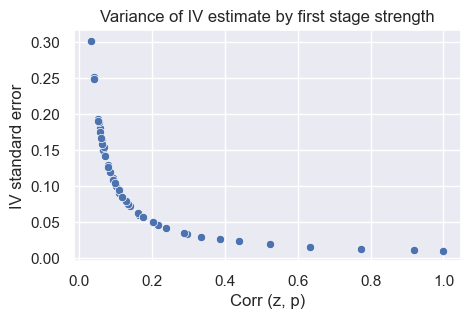

In [28]:
plot_df = pd.DataFrame({'se': se, 'ate': ate, 'ci_lower': ci_lower, 'ci_upper': ci_upper}, index=corr_df.index)
# pd.concat([plot_df, corr_df], axis=1, ignore_index=True)
plot_df = pd.concat([plot_df, corr_df], axis=1)
plot_df.rename(columns={'P': 'corr'}, inplace=True)

fig, ax = plt.subplots(figsize=(5, 3))

sns.scatterplot(data=plot_df, x='corr', y='se', ax=ax)

ax.set_xlabel('Corr (z, p)')
ax.set_ylabel('IV standard error')
ax.set_title('Variance of IV estimate by first stage strength')

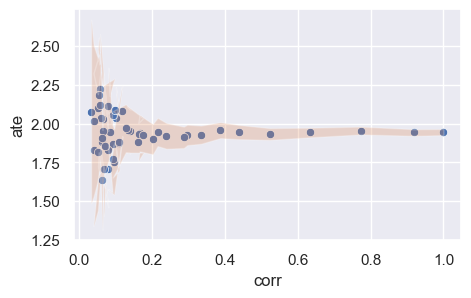

In [29]:
fig, ax = plt.subplots(figsize=(5, 3))

sns.scatterplot(data=plot_df, x='corr', y='ate', ax=ax)
ax.fill_between(x=plot_df['corr'], y1=plot_df['ci_lower'], y2=plot_df['ci_upper'], alpha=.25)


* Estimates vary a lot when correlation between $z$ and $p$ is low
* Overall, 2SLS estimates are biased (they don't quite hit 2, the dfined effect!). This is because 2SLS is biased towards OLS